## Import Libraries

In [1]:
import os

os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"

In [2]:
import numpy as np

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

## Prepare train dataset

In [3]:
# Transform to turn into tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307),(0.3081,)) # mean y std
])

In [4]:
# Load the dataset and normalize it
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform
)

## Prepare test dataset

In [5]:
transform_test = transforms.ToTensor()

In [6]:
# Load the test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

## Data Loaders

In [7]:
# DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=512,
    num_workers=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=1028,
    num_workers=4,
    shuffle=True,
    drop_last=False
)

## Feed Forward Network 

In [8]:
# All variables
%whos

Variable         Type          Data/Info
----------------------------------------
DataLoader       type          <class 'torch.utils.data.dataloader.DataLoader'>
F                module        <module 'torch.nn.functio<...>/torch/nn/functional.py'>
datasets         module        <module 'torchvision.data<...>on/datasets/__init__.py'>
nn               module        <module 'torch.nn' from '<...>es/torch/nn/__init__.py'>
np               module        <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
os               module        <module 'os' (frozen)>
plt              module        <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
test_dataset     MNIST         Dataset MNIST\n    Number<...>rm\nTransform: ToTensor()
test_loader      DataLoader    <torch.utils.data.dataloa<...>object at 0x792f46dc2d20>
torch            module        <module 'torch' from '/ho<...>kages/torch/__init__.py'>
train_dataset    MNIST         Dataset MNIST\n    Number<...>=(0.3081,))\n           )
t

In [9]:
import torch

print(f"¿GPU disponible?: {torch.cuda.is_available()}")
print(f"Nombre de la GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Ninguna'}")

¿GPU disponible?: True
Nombre de la GPU: AMD Radeon RX 6600


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

Entrenando en: cuda


In [11]:
def createTheMNISTNet():

    class mnistNet(nn.Module):
        def __init__(self):
            super().__init__()

            # input layer
            self.input = nn.Linear(784,64) # 784 pixels

            # hidden layer
            self.fc1 = nn.Linear(64,32)
            self.fc2 = nn.Linear(32,32)

            # output layer
            self.output = nn.Linear(32,10)

        def forward(self,x):
            x = x.view(x.shape[0], -1)
            
            x = F.relu( self.input(x) )
            x = F.relu( self.fc1(x) )
            x = F.relu( self.fc2(x) )
            return torch.log_softmax( self.output(x), dim=1 )

    net = mnistNet()

    lossfun = nn.NLLLoss()

    optimizer = torch.optim.SGD(net.parameters(), lr=0.1) # try with Adam later

    return net, lossfun, optimizer

In [12]:
net, lossfun, optimizer = createTheMNISTNet()

X,y = next(iter(train_loader))
yHat = net(X)

print(yHat)

loss = lossfun(yHat, y)
print(' ')
print('Loss:')
print(loss)

tensor([[-2.1107, -2.3819, -2.3326,  ..., -2.4748, -2.4636, -2.1852],
        [-2.1344, -2.4172, -2.2901,  ..., -2.4712, -2.4480, -2.2138],
        [-2.1072, -2.3897, -2.3171,  ..., -2.4568, -2.4828, -2.2517],
        ...,
        [-2.1329, -2.4031, -2.3068,  ..., -2.4710, -2.4253, -2.2202],
        [-2.1185, -2.3938, -2.3375,  ..., -2.4492, -2.4651, -2.2211],
        [-2.1255, -2.3978, -2.3363,  ..., -2.4340, -2.4766, -2.2327]],
       grad_fn=<LogSoftmaxBackward0>)
 
Loss:
tensor(2.3182, grad_fn=<NllLossBackward0>)


## Training

In [13]:
def function2trainTheModel():

    numepochs = 60

    net, lossfun, optimizer = createTheMNISTNet()
    net.to(device)

    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):

        # ===== Train =====
        batchAcc = []
        batchLoss = []
        for X,y in train_loader:

            X, y = X.to(device), y.to(device)
            
            # forward
            yHat = net(X)
            loss = lossfun(yHat, y)

            # back
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # loss
            batchLoss.append( loss.item() )

            # accuracy
            matches = torch.argmax(yHat, axis=1) == y # predictions
            matchesNumeric = matches.float() # to numeric
            accuracyPct = 100*torch.mean(matchesNumeric) # pct of mean
            batchAcc.append( accuracyPct.item() ) # add

        trainAcc.append( np.mean(batchAcc) )

        losses[epochi] = np.mean(batchLoss)

        # ===== Test =====
        X,y = next(iter(test_loader))
        X, y = X.to(device), y.to(device)
        yHat = net(X)

        acc = 100*torch.mean( (torch.argmax(yHat, axis=1)==y).float() )
        testAcc.append( acc.item() )
        
        print(f'Epoch: {epochi} \f trainAcc: {trainAcc[epochi]} \f testAcc: {testAcc[epochi]}')

    return trainAcc, testAcc, losses, net

In [14]:
trainAcc, testAcc, losses, net = function2trainTheModel()

/home/alexpy/Documents/DLNotes/.venv/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:310.)
  return F.linear(input, self.weight, self.bias)


Epoch: 0  trainAcc: 61.45332532051282  testAcc: 85.311279296875
Epoch: 1  trainAcc: 89.38134348290598  testAcc: 90.56420135498047
Epoch: 2  trainAcc: 92.25761217948718  testAcc: 90.6614761352539
Epoch: 3  trainAcc: 93.66653311965813  testAcc: 91.2451400756836
Epoch: 4  trainAcc: 94.6514423076923  testAcc: 92.50972747802734
Epoch: 5  trainAcc: 95.3926282051282  testAcc: 92.4124526977539
Epoch: 6  trainAcc: 95.9067841880342  testAcc: 92.89883422851562
Epoch: 7  trainAcc: 96.25734508547009  testAcc: 94.16342163085938
Epoch: 8  trainAcc: 96.58286591880342  testAcc: 94.35797882080078
Epoch: 9  trainAcc: 96.80154914529915  testAcc: 93.57977294921875
Epoch: 10  trainAcc: 97.1187232905983  testAcc: 95.33074188232422
Epoch: 11  trainAcc: 97.28732638888889  testAcc: 94.8443603515625
Epoch: 12  trainAcc: 97.41085737179488  testAcc: 95.42801666259766
Epoch: 13  trainAcc: 97.74639423076923  testAcc: 95.13619232177734
Epoch: 14  trainAcc: 97.81817574786325  testAcc: 95.

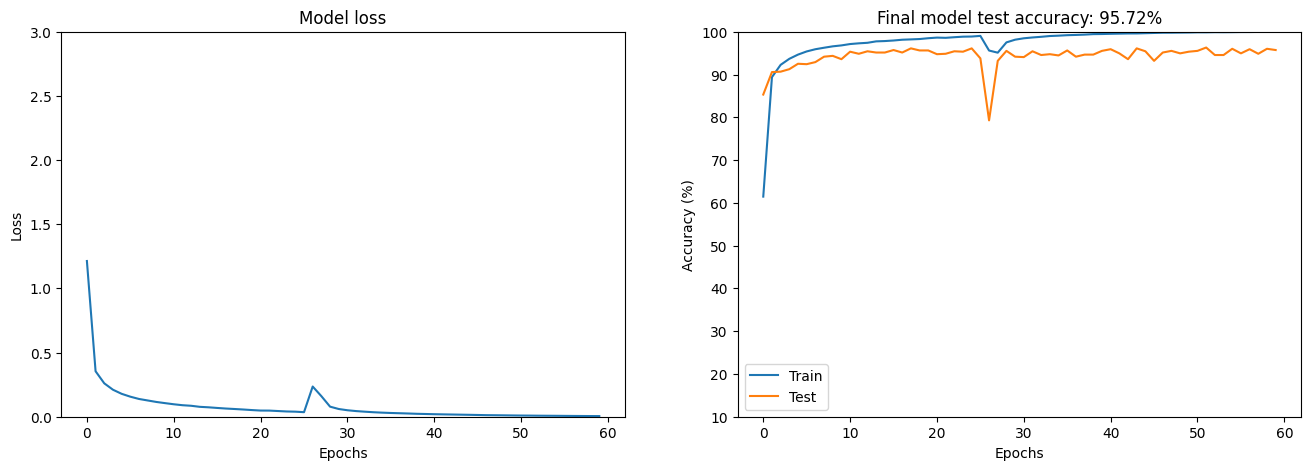

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0,3])
ax[0].set_title('Model loss')

ax[1].plot(trainAcc, label='Train')
ax[1].plot(testAcc, label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_ylim([10,100])
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()


Se encontraron 52 errores en este batch.




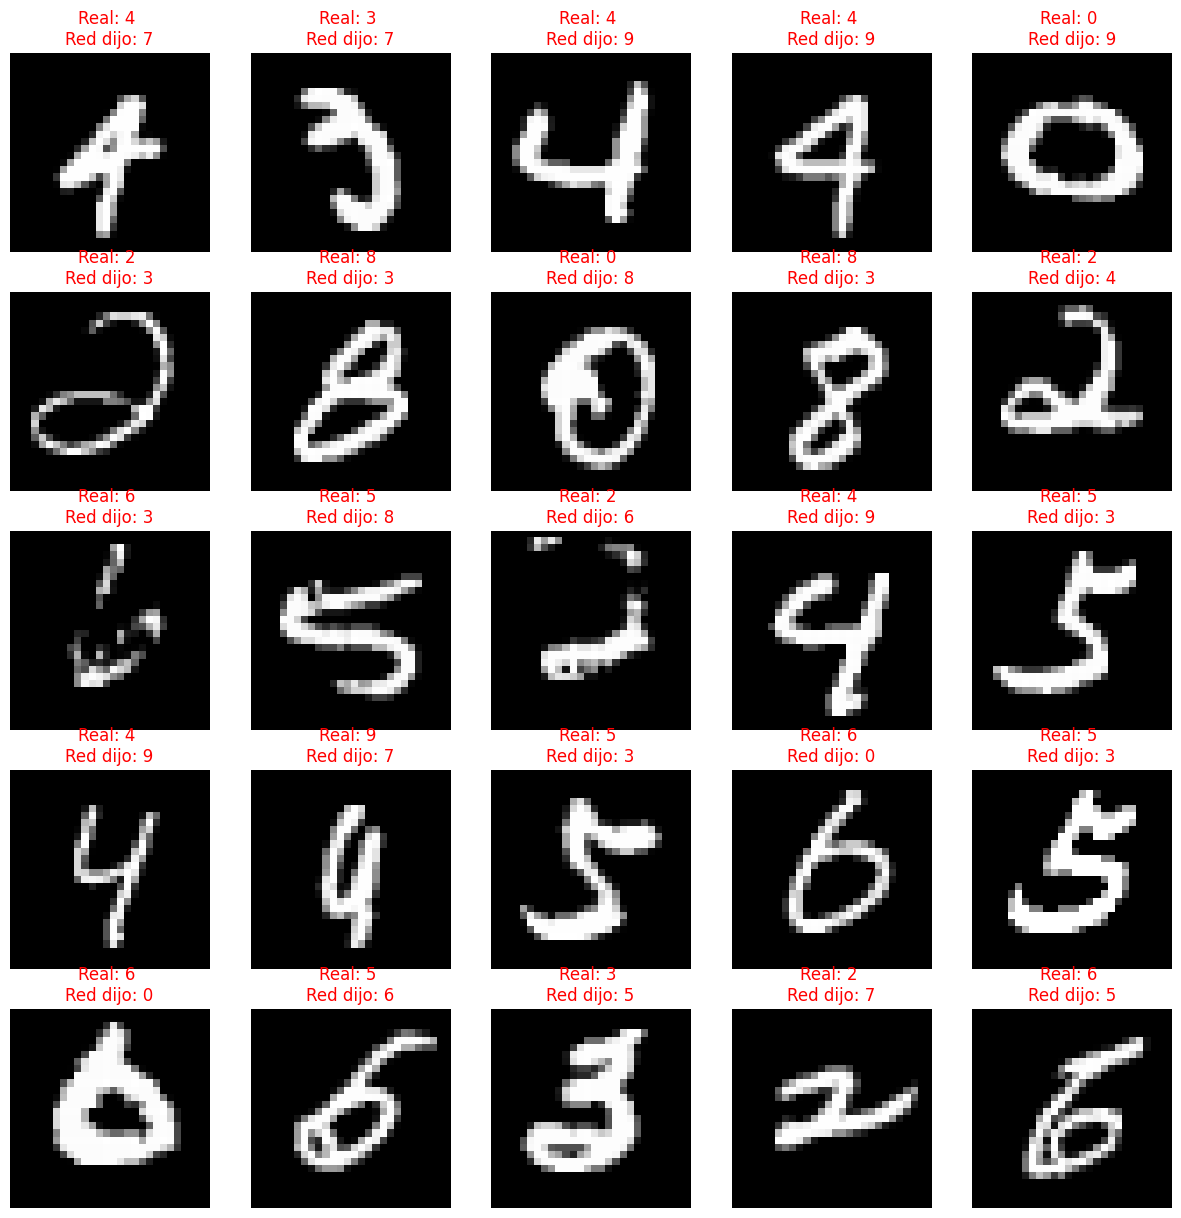

In [30]:
import math
import matplotlib.pyplot as plt
import torch

X, y = next(iter(test_loader))
X, y = X.to(device), y.to(device)

with torch.no_grad():
    predictions = net(X)

predictions = predictions.cpu()
y = y.cpu()
X = X.cpu()

predicted_classes = torch.argmax(predictions, dim=1)
errors = torch.where(predicted_classes != y)[0]

num_errors = len(errors)
print(f'\nSe encontraron {num_errors} errores en este batch.\n\n')

if num_errors > 0:
    max_to_show = min(num_errors, 25) 
    
    cols = 5 
    rows = math.ceil(max_to_show / cols)
    
    fig = plt.figure(figsize=(15, rows * 3))
    
    for i in range(max_to_show):
        error_idx = errors[i]
        true_val = y[error_idx].item()
        guess_val = predicted_classes[error_idx].item()
        
        ax = fig.add_subplot(rows, cols, i + 1)
        
        img_to_show = X[error_idx].view(28, 28)
        ax.imshow(img_to_show, cmap='gray')
        
        ax.set_title(f'Real: {true_val} \nRed dijo: {guess_val}', color='red')
        ax.axis('off') 